In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/marketing_sales_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)

(60000, 23)


In [2]:
df["discount_percentage"] = df["discount_percentage"].fillna(
    df["discount_percentage"].median()
)

df["customer_satisfaction_score"] = df["customer_satisfaction_score"].fillna(
    df["customer_satisfaction_score"].median()
)

df["email_open_rate"] = df["email_open_rate"].fillna(
    df["email_open_rate"].median()
)

df["days_since_last_purchase"] = df["days_since_last_purchase"].fillna(
    df["days_since_last_purchase"].median()
)

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [3]:
missing_decision = pd.DataFrame({
    "Column": [
        "discount_percentage",
        "customer_satisfaction_score",
        "email_open_rate",
        "days_since_last_purchase"
    ],
    "Missing_Count": [
        1808,
        1844,
        1790,
        1836
    ],
    "Treatment": [
        "Median Imputation",
        "Median Imputation",
        "Median Imputation",
        "Median Imputation"
    ],
    "Reason": [
        "Robust to outliers",
        "Robust to outliers",
        "Robust to outliers",
        "Robust to outliers"
    ]
})

print(missing_decision)

                        Column  Missing_Count          Treatment  \
0          discount_percentage           1808  Median Imputation   
1  customer_satisfaction_score           1844  Median Imputation   
2              email_open_rate           1790  Median Imputation   
3     days_since_last_purchase           1836  Median Imputation   

               Reason  
0  Robust to outliers  
1  Robust to outliers  
2  Robust to outliers  
3  Robust to outliers  


In [4]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['region', 'sales_channel', 'product_category', 'customer_segment', 'season']


C:\Users\PC\AppData\Local\Temp\ipykernel_14440\2798951942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [5]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

Original shape: (60000, 23)
Encoded shape: (60000, 38)


In [6]:
correlation_matrix = df_encoded.select_dtypes(include="number").corr()

high_correlation = correlation_matrix[
    (correlation_matrix.abs() > 0.8) &
    (correlation_matrix.abs() < 1.0)
]

print("Highly correlated feature pairs:")
print(high_correlation.dropna(how="all").dropna(axis=1, how="all"))

Highly correlated feature pairs:
                      marketing_budget_usd  ad_spend_online_usd  \
marketing_budget_usd                   NaN             0.948279   
ad_spend_online_usd               0.948279                  NaN   
ad_spend_offline_usd              0.929485             0.889061   

                      ad_spend_offline_usd  
marketing_budget_usd              0.929485  
ad_spend_online_usd               0.889061  
ad_spend_offline_usd                   NaN  


In [7]:
features_to_remove = [
    "total_ad_spend_usd",
    "quarter"
]

existing_features = [
    col for col in features_to_remove
    if col in df_encoded.columns
]

df_selected = df_encoded.drop(columns=existing_features)

print("Removed highly correlated features:")
print(existing_features)
print("Shape after feature selection:", df_selected.shape)

Removed highly correlated features:
[]
Shape after feature selection: (60000, 38)


In [8]:
import pandera as pa

schema = pa.DataFrameSchema({
    "sales_revenue_usd": pa.Column(float, nullable=False),
    "marketing_budget_usd": pa.Column(float, nullable=False),
    "customer_age": pa.Column(int, nullable=False)
})

validated_df = schema.validate(df)

print("Pandera validation passed successfully!")

Pandera validation passed successfully!


c:\Users\PC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandera\_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


In [9]:
selected_features = [
    column for column in df_selected.columns
    if column != "sales_revenue_usd"
]

print("Number of selected features:", len(selected_features))
print("Selected features:")
print(selected_features)

Number of selected features: 37
Selected features:
['id', 'date', 'marketing_budget_usd', 'ad_spend_online_usd', 'ad_spend_offline_usd', 'num_promotions', 'discount_percentage', 'num_sales_representatives', 'customer_age', 'customer_satisfaction_score', 'competitor_price_index', 'website_traffic', 'conversion_rate', 'email_open_rate', 'social_media_followers', 'days_since_last_purchase', 'num_previous_purchases', 'region_Amman', 'region_Cairo', 'region_Casablanca', 'region_Dubai', 'region_Kuwait', 'region_Riyadh', 'sales_channel_Online', 'sales_channel_Retail Store', 'sales_channel_Social Media', 'sales_channel_Wholesale', 'product_category_Cosmetics', 'product_category_Electronics', 'product_category_Food & Beverage', 'product_category_Home Appliances', 'customer_segment_New', 'customer_segment_Regular', 'customer_segment_VIP', 'season_Q2', 'season_Q3', 'season_Q4']


In [10]:
print("Point-in-Time / Data Leakage Check")

print("Date column data type:", df["date"].dtype)

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

print("Future dates present:", (df["date"] > pd.Timestamp.today()).sum())

print("Target column:", "sales_revenue_usd")
print("Target is not used to create input features.")

Point-in-Time / Data Leakage Check
Date column data type: datetime64[us]
Minimum date: 2020-01-01 00:00:00
Maximum date: 2023-12-31 00:00:00
Future dates present: 0
Target column: sales_revenue_usd
Target is not used to create input features.


# Project Introduction

This project focuses on Advanced Exploratory Data Analysis (EDA) and Feature Engineering using a Marketing and Sales dataset.

The main objective is to clean and preprocess the dataset, analyze patterns and relationships in the data, identify and treat outliers, handle missing values, encode categorical variables, and create useful features for further data analysis and machine learning.


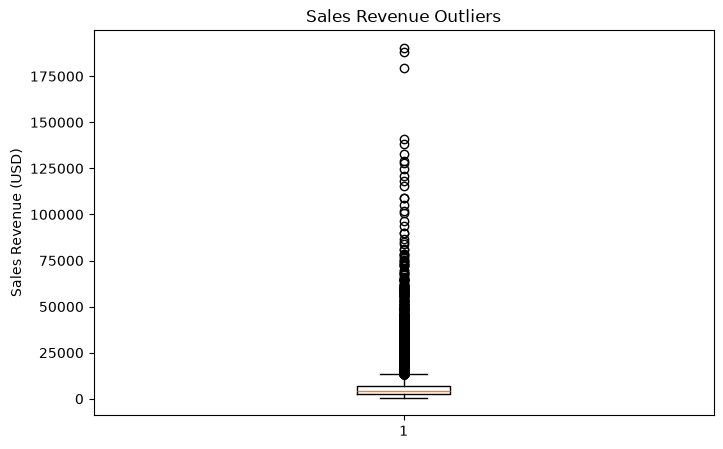

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df["sales_revenue_usd"])
plt.title("Sales Revenue Outliers")
plt.ylabel("Sales Revenue (USD)")
plt.show()

# Dataset Overview

The dataset contains 60,000 rows and 23 original columns. It contains information related to marketing activities, advertising spending, customer characteristics, sales channels, product categories, and sales revenue.

The dataset includes numerical, categorical, and date-based variables. The target variable used for analysis is `sales_revenue_usd`.

The dataset was selected to perform exploratory data analysis, data cleaning, outlier treatment, categorical encoding, and feature engineering.


In [12]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (60000, 23)

First 5 Rows:
   id       date  region sales_channel product_category customer_segment  \
0   1 2020-11-12  Riyadh  Retail Store        Cosmetics          Regular   
1   2 2022-07-05   Dubai        Online        Cosmetics              New   
2   3 2020-11-11  Riyadh        Online      Electronics          Regular   
3   4 2022-10-01   Cairo        Online      Electronics          Regular   
4   5 2023-12-12   Cairo  Retail Store  Food & Beverage        Corporate   

  season  marketing_budget_usd  ad_spend_online_usd  ad_spend_offline_usd  \
0     Q4               1664.51               952.30                326.97   
1     Q3               2452.29              1014.25                414.76   
2     Q4               1026.13               328.30                242.72   
3     Q4               1102.86               628.30                204.58   
4     Q4               2517.55               777.24                817.88   

   ...  customer_age  customer_satisfa

In [13]:
%pip install pandera

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
numeric_columns = [
    "marketing_budget_usd",
    "ad_spend_online_usd",
    "ad_spend_offline_usd",
    "customer_age",
    "customer_satisfaction_score",
    "competitor_price_index",
    "website_traffic",
    "conversion_rate",
    "email_open_rate",
    "social_media_followers",
    "days_since_last_purchase",
    "num_previous_purchases",
    "sales_revenue_usd"
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[column] < lower) | (df[column] > upper)).sum()

    print(column, ":", count, "outliers")

marketing_budget_usd : 5459 outliers
ad_spend_online_usd : 5563 outliers
ad_spend_offline_usd : 5611 outliers
customer_age : 0 outliers
customer_satisfaction_score : 0 outliers
competitor_price_index : 0 outliers
website_traffic : 6504 outliers
conversion_rate : 1460 outliers
email_open_rate : 744 outliers
social_media_followers : 8068 outliers
days_since_last_purchase : 0 outliers
num_previous_purchases : 806 outliers
sales_revenue_usd : 3816 outliers


In [15]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["day_of_week"] = df["date"].dt.dayofweek

print(df[["date", "year", "month", "quarter", "day_of_week"]].head())

        date  year  month  quarter  day_of_week
0 2020-11-12  2020     11        4            3
1 2022-07-05  2022      7        3            1
2 2020-11-11  2020     11        4            2
3 2022-10-01  2022     10        4            5
4 2023-12-12  2023     12        4            1


In [16]:
df["total_ad_spend_usd"] = (
    df["ad_spend_online_usd"] + df["ad_spend_offline_usd"]
)

print(df[[
    "ad_spend_online_usd",
    "ad_spend_offline_usd",
    "total_ad_spend_usd"
]].head())

   ad_spend_online_usd  ad_spend_offline_usd  total_ad_spend_usd
0               952.30                326.97             1279.27
1              1014.25                414.76             1429.01
2               328.30                242.72              571.02
3               628.30                204.58              832.88
4               777.24                817.88             1595.12


In [17]:
df["marketing_efficiency"] = (
    df["sales_revenue_usd"] / df["total_ad_spend_usd"]
)

print(df[[
    "sales_revenue_usd",
    "total_ad_spend_usd",
    "marketing_efficiency"
]].head())

   sales_revenue_usd  total_ad_spend_usd  marketing_efficiency
0            3772.90             1279.27              2.949260
1            2091.36             1429.01              1.463503
2            6201.11              571.02             10.859707
3            4911.38              832.88              5.896864
4            7705.73             1595.12              4.830815


In [18]:
df["purchase_frequency"] = (
    df["num_previous_purchases"] / (df["days_since_last_purchase"] + 1)
)

print(df[[
    "num_previous_purchases",
    "days_since_last_purchase",
    "purchase_frequency"
]].head())

   num_previous_purchases  days_since_last_purchase  purchase_frequency
0                       6                      25.0            0.230769
1                       7                     187.0            0.037234
2                       3                     139.0            0.021429
3                       6                     308.0            0.019417
4                       6                      97.0            0.061224


In [19]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

print(correlation["sales_revenue_usd"].sort_values(ascending=False))

sales_revenue_usd              1.000000
marketing_budget_usd           0.727301
total_ad_spend_usd             0.710056
ad_spend_online_usd            0.698200
ad_spend_offline_usd           0.679897
quarter                        0.169241
month                          0.164378
num_previous_purchases         0.048060
conversion_rate                0.039513
customer_satisfaction_score    0.039404
num_promotions                 0.037726
marketing_efficiency           0.026247
website_traffic                0.017426
purchase_frequency             0.006340
customer_age                   0.006021
year                           0.005100
day_of_week                    0.005088
email_open_rate                0.004430
id                            -0.000340
social_media_followers        -0.001325
num_sales_representatives     -0.003491
days_since_last_purchase      -0.009812
competitor_price_index        -0.017224
discount_percentage           -0.021929
Name: sales_revenue_usd, dtype: float64


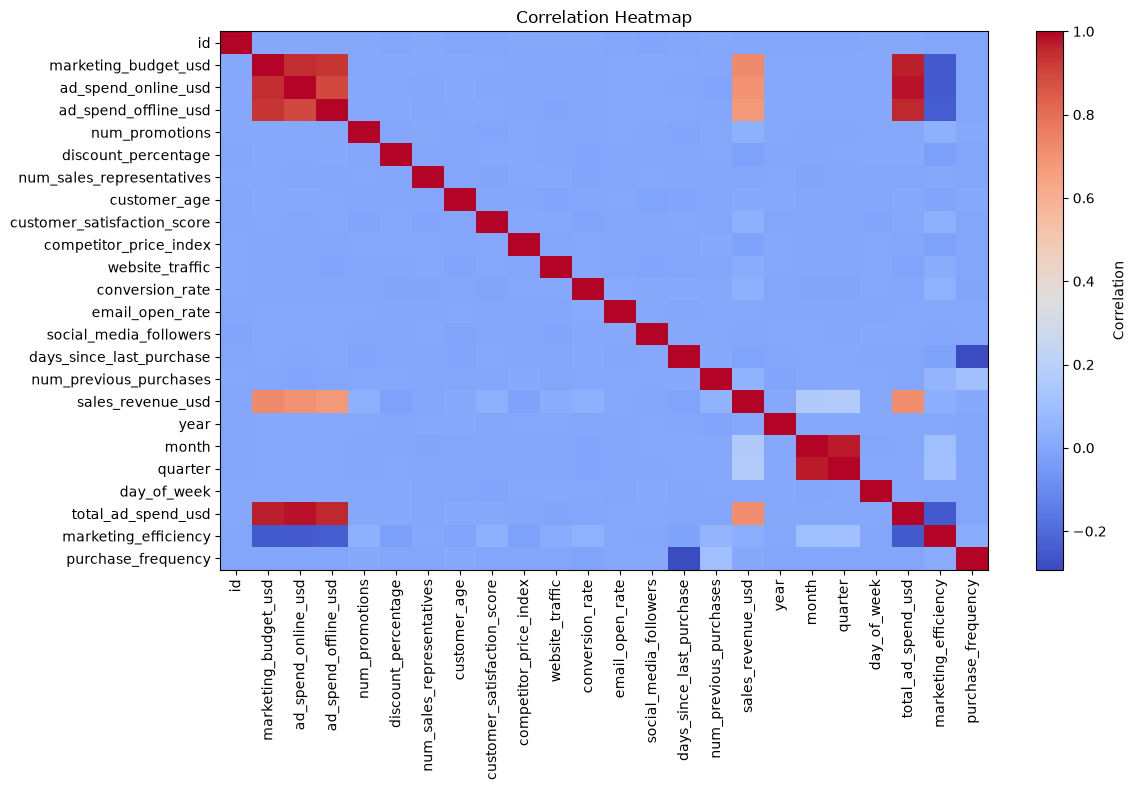

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.tight_layout()
plt.show()

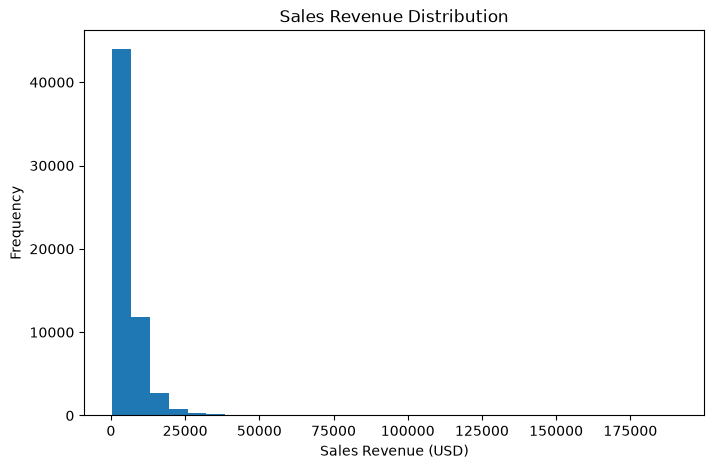

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df["sales_revenue_usd"], bins=30)
plt.title("Sales Revenue Distribution")
plt.xlabel("Sales Revenue (USD)")
plt.ylabel("Frequency")
plt.show()

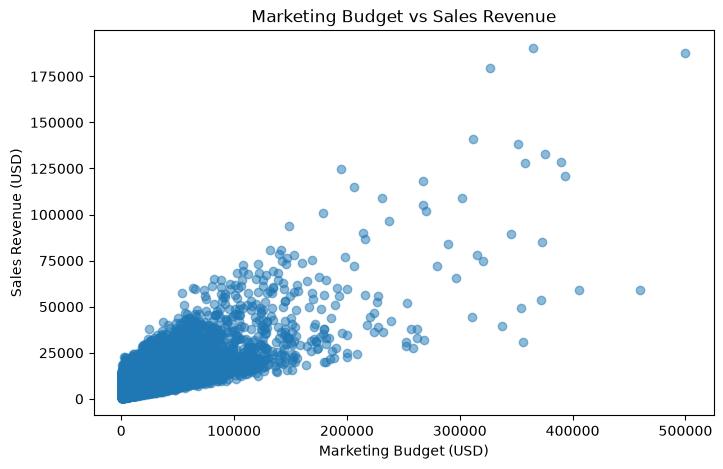

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df["marketing_budget_usd"], df["sales_revenue_usd"], alpha=0.5)
plt.title("Marketing Budget vs Sales Revenue")
plt.xlabel("Marketing Budget (USD)")
plt.ylabel("Sales Revenue (USD)")
plt.show()

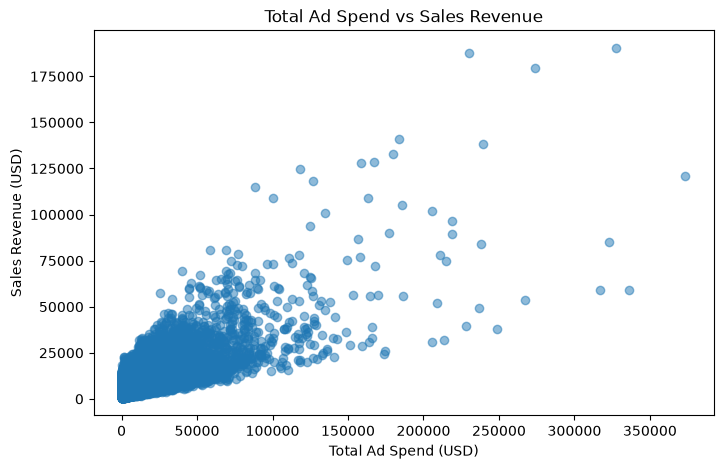

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df["total_ad_spend_usd"], df["sales_revenue_usd"], alpha=0.5)
plt.title("Total Ad Spend vs Sales Revenue")
plt.xlabel("Total Ad Spend (USD)")
plt.ylabel("Sales Revenue (USD)")
plt.show()

In [24]:
Q1 = df["sales_revenue_usd"].quantile(0.25)
Q3 = df["sales_revenue_usd"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df["sales_revenue_capped"] = df["sales_revenue_usd"].clip(
    lower=lower_limit,
    upper=upper_limit
)

print("Original minimum:", df["sales_revenue_usd"].min())
print("Capped minimum:", df["sales_revenue_capped"].min())
print("Original maximum:", df["sales_revenue_usd"].max())
print("Capped maximum:", df["sales_revenue_capped"].max())

Original minimum: 481.08
Capped minimum: 481.08
Original maximum: 190377.35
Capped maximum: 13612.811249999999


In [25]:
original_outliers = (
    (df["sales_revenue_usd"] < lower_limit) |
    (df["sales_revenue_usd"] > upper_limit)
).sum()

capped_outliers = (
    (df["sales_revenue_capped"] < lower_limit) |
    (df["sales_revenue_capped"] > upper_limit)
).sum()

print("Original outliers:", original_outliers)
print("Outliers after capping:", capped_outliers)

Original outliers: 3816
Outliers after capping: 0


In [26]:
print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

print("\nNew features:")
print([
    "year",
    "month",
    "quarter",
    "day_of_week",
    "total_ad_spend_usd",
    "marketing_efficiency",
    "purchase_frequency",
    "sales_revenue_capped"
])

Dataset shape: (60000, 31)
Total missing values: 0
Total duplicate rows: 0

New features:
['year', 'month', 'quarter', 'day_of_week', 'total_ad_spend_usd', 'marketing_efficiency', 'purchase_frequency', 'sales_revenue_capped']


In [27]:
df.to_csv("../data/processed/marketing_sales_processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [28]:
print("PROJECT 1 - FINAL FINDINGS")
print("---------------------------")
print("Dataset size: 60,000 rows and 23 original columns")
print("Missing values after imputation: 0")
print("Duplicate rows: 0")
print("Sales revenue outliers detected: 3,816")
print("Sales revenue outliers after IQR capping: 0")
print("Engineered features added: 8")
print("Processed dataset saved successfully.")
print()
print("Strongest correlations with sales revenue:")
print("Marketing budget:", round(correlation["sales_revenue_usd"]["marketing_budget_usd"], 3))
print("Total ad spend:", round(correlation["sales_revenue_usd"]["total_ad_spend_usd"], 3))
print("Online ad spend:", round(correlation["sales_revenue_usd"]["ad_spend_online_usd"], 3))
print("Offline ad spend:", round(correlation["sales_revenue_usd"]["ad_spend_offline_usd"], 3))

PROJECT 1 - FINAL FINDINGS
---------------------------
Dataset size: 60,000 rows and 23 original columns
Missing values after imputation: 0
Duplicate rows: 0
Sales revenue outliers detected: 3,816
Sales revenue outliers after IQR capping: 0
Engineered features added: 8
Processed dataset saved successfully.

Strongest correlations with sales revenue:
Marketing budget: 0.727
Total ad spend: 0.71
Online ad spend: 0.698
Offline ad spend: 0.68
